In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [102]:
master_df = pd.read_csv("../data/processed/master_dataset_v2.csv")
df = master_df.copy()

In [103]:
df.head()

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp
0,Alabama,2008,4718206.0,1.746656e+11,37019.49,2582600.0,0.547369,33441.0,42219.0,88.901
1,Alabama,2009,4757938.0,1.708765e+11,35913.98,2479511.0,0.521131,32717.0,41966.0,87.786
2,Alabama,2010,4788095.0,1.775107e+11,37073.35,2460305.0,0.513838,33848.0,41709.0,89.783
3,Alabama,2011,4812576.0,1.828967e+11,38003.91,2497974.0,0.519051,34884.0,41819.0,90.011
4,Alabama,2012,4839947.0,1.882807e+11,38901.40,2503656.0,0.517290,35559.0,41592.0,90.559


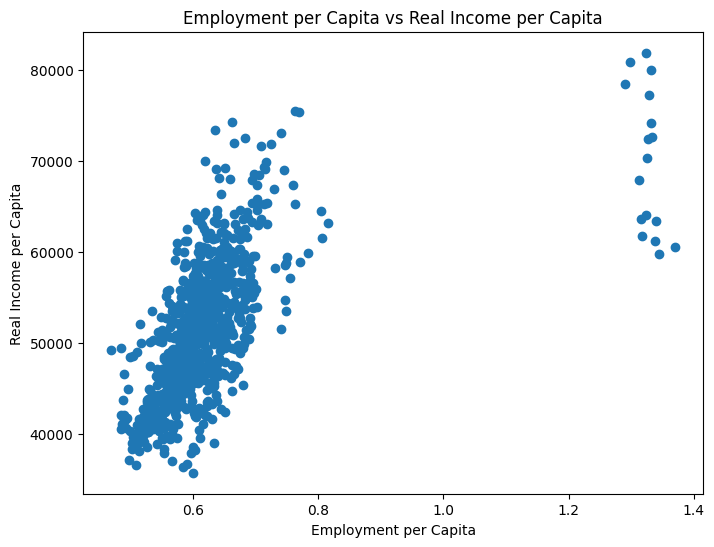

In [104]:
plt.figure(figsize=(8,6))
plt.scatter(df["employment_pc"], df["real_income_pc"])
plt.xlabel("Employment per Capita")
plt.ylabel("Real Income per Capita")
plt.title("Employment per Capita vs Real Income per Capita")
plt.show()

In [105]:
df_no_dc = df[df["state"] != "District of Columbia"].copy()

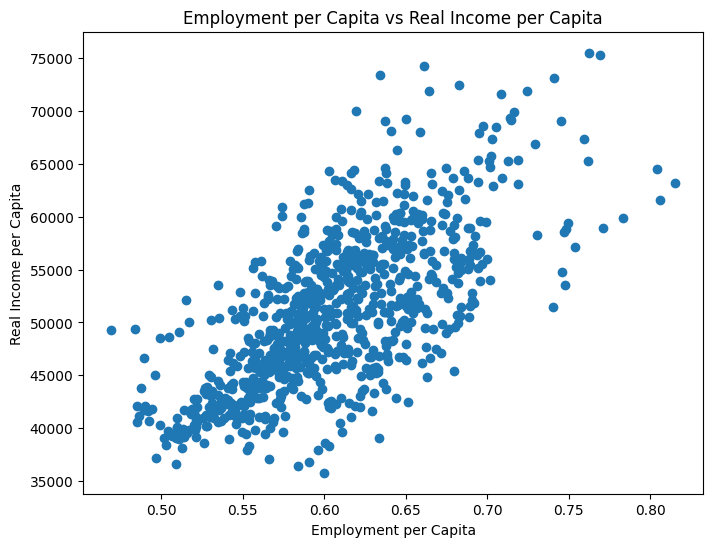

In [106]:
plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["employment_pc"], df_no_dc["real_income_pc"])
plt.xlabel("Employment per Capita")
plt.ylabel("Real Income per Capita")
plt.title("Employment per Capita vs Real Income per Capita")
plt.show()

In [107]:
df_no_dc["employment_pc"].corr(df_no_dc["real_income_pc"])

np.float64(0.6908320616202509)

In [108]:
import statsmodels.api as sm

# Perform linear regression
X = df_no_dc[['employment_pc']]
y = df_no_dc['real_income_pc']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         real_income_pc   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     774.2
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.43e-121
Time:                        17:28:11   Log-Likelihood:                -8491.7
No. Observations:                 850   AIC:                         1.699e+04
Df Residuals:                     848   BIC:                         1.700e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4679.3021   2009.061     -2.329

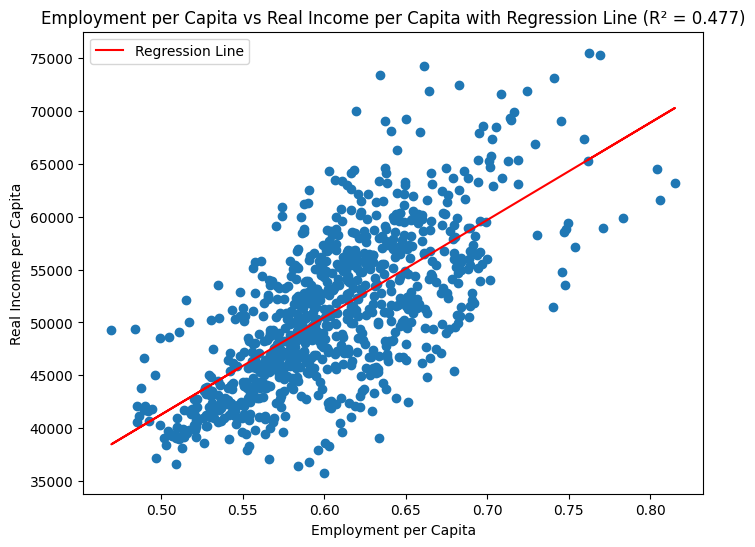

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_no_dc["employment_pc"], df_no_dc["real_income_pc"])
plt.plot(df_no_dc["employment_pc"], model.predict(X), color='red', label='Regression Line')
plt.xlabel("Employment per Capita")
plt.ylabel("Real Income per Capita")
plt.title(f"Employment per Capita vs Real Income per Capita with Regression Line (R² = {model.rsquared:.3f})")
plt.legend()
plt.show()

In [110]:
df_no_dc["predicted"] = model.predict(X)
df_no_dc["residual"] = df_no_dc["real_income_pc"] - df_no_dc["predicted"]


In [111]:
# worst
df_no_dc.sort_values("residual").head(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
749,Utah,2009,2723421.0,1.138348e+11,41798.46,1633986.0,0.599976,31796.0,35790.0,100.037,50481.973096,-14691.973096
748,Utah,2008,2663029.0,1.169492e+11,43915.86,1688135.0,0.633915,33784.0,39100.0,96.978,53602.373132,-14502.373132
751,Utah,2011,2818798.0,1.251378e+11,44394.03,1664413.0,0.590469,34015.0,36773.0,99.813,49607.954196,-12834.954196
442,Montana,2008,976415.0,3.702800e+10,37922.40,636195.0,0.651562,35569.0,42435.0,94.079,55224.799211,-12789.799211
750,Utah,2010,2776212.0,1.182963e+11,42610.69,1620793.0,0.583815,32037.0,36430.0,97.291,48996.145349,-12566.145349
753,Utah,2013,2909190.0,1.353443e+11,46523.02,1753374.0,0.602702,36102.0,38281.0,98.587,50732.621207,-12451.621207
765,Vermont,2008,624151.0,2.614040e+10,41881.53,424280.0,0.679771,40774.0,45453.0,100.686,57818.340727,-12365.340727
752,Utah,2012,2861360.0,1.294314e+11,45234.22,1706044.0,0.596235,35622.0,37956.0,99.412,50138.103104,-12182.103104
754,Utah,2014,2951948.0,1.426277e+11,48316.47,1803933.0,0.611099,37621.0,39603.0,97.937,51504.671153,-11901.671153
579,North Dakota,2009,664968.0,3.231040e+10,48589.41,492409.0,0.740500,40186.0,51506.0,87.852,63401.706947,-11895.706947


In [112]:
# best
df_no_dc.sort_values("residual").tail(20)

,state,year,population,gdp,gdp_pc,employment,employment_pc,income_pc,real_income_pc,rpp,predicted,residual
556,New York,2020,20122262.0,1.782502e+12,88583.60,11871200.0,0.589954,70412.0,61253.0,110.130,49560.559245,11692.440755
506,New Hampshire,2021,1387907.0,9.943330e+10,71642.62,894652.0,0.644605,73982.0,66325.0,102.568,54585.183499,11739.816501
81,California,2021,39152927.0,3.418256e+12,87305.25,23932245.0,0.611250,77134.0,63373.0,111.918,51518.580632,11854.419368
659,Pennsylvania,2021,13016628.0,8.448755e+11,64907.40,7648662.0,0.587607,64008.0,61217.0,96.145,49344.820761,11872.179239
811,Washington,2020,7726812.0,6.177391e+11,79947.47,4435243.0,0.574007,67665.0,60102.0,107.859,48094.431660,12007.568340
557,New York,2021,19835345.0,1.934524e+12,97529.13,12226675.0,0.616408,76360.0,64085.0,109.564,51992.804688,12092.195312
369,Massachusetts,2020,6985320.0,5.928555e+11,84871.63,4600531.0,0.658600,77493.0,68048.0,109.101,55871.848991,12176.151009
815,Washington,2024,7927958.0,8.560136e+11,107974.03,4904120.0,0.618586,85187.0,64421.0,107.013,52192.959121,12228.040879
104,Connecticut,2010,3580281.0,2.340222e+11,65364.20,2171940.0,0.606640,61392.0,63477.0,106.999,51094.654976,12382.345024
812,Washington,2021,7744316.0,6.833670e+11,88241.10,4574704.0,0.590718,73949.0,62496.0,108.804,49630.807778,12865.192222


In [113]:
state_avg = df_no_dc.groupby("state")["residual"].mean().sort_values()

In [114]:
state_avg.head(10)

state
Utah           -8955.222217
Hawaii         -6829.053064
Vermont        -6147.289749
Montana        -4542.982618
North Dakota   -4455.746020
Idaho          -3768.383486
Oregon         -3677.305972
Maine          -3656.041610
Colorado       -2582.275992
Iowa           -2422.382232
Name: residual, dtype: float64

In [115]:
state_avg.tail(10)

state
California        2838.994547
Alaska            2989.275617
Maryland          3739.626126
Pennsylvania      3745.848672
West Virginia     3762.034214
Washington        4067.619325
New York          4295.249734
Massachusetts     5030.537748
New Jersey        6825.546228
Connecticut      12483.883255
Name: residual, dtype: float64

In [116]:
df_no_dc["employment_group"] = pd.qcut(df_no_dc["employment_pc"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])
df_no_dc.groupby("employment_group")["residual"].mean()

employment_group
Low        -687.612744
Mid-Low     404.255712
Mid-High    510.240542
High       -222.590100
Name: residual, dtype: float64

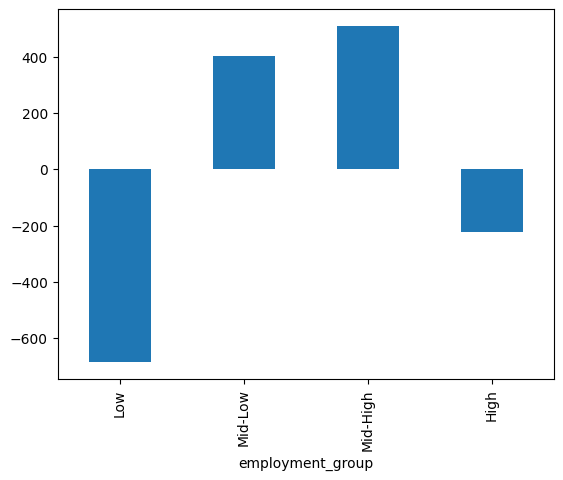

In [117]:
ax = df_no_dc.groupby("employment_group")["residual"].mean().plot(kind="bar")

In [118]:
groups = [group["residual"].values for name, group in df_no_dc.groupby("employment_group")]

f_stat, p_value = stats.f_oneway(*groups)
print(p_value)

0.06519634641452171
